# 🧠 Milestone 5: Model Training & Feature Optimization

**Project:** Network Intrusion Detection System (CICIDS-2017)  
**Team:** Dina Fawzy – Mohamed Farag – Pola Mokhtar – Ahmed Mamdouh – Mustafa Ibrahim  
**Team Leader:** Ahmed Mamdouh  
**Google Drive:** https://drive.google.com/drive/folders/1wa5Y5heNduaFH-T2bIkQAkoXlhiy0QCe?usp=sharing  
**Github Repo:** https://github.com/AhmedELNajjar-dev/Depi-Final-Project   
**Goal:** Train a Random Forest Classifier, optimize its settings, and select the best features to maximize detection accuracy.
### 📋 Overview
In this milestone, we will replicate the paper's machine learning methodology through the following steps:
1.  **Load Data:** Import the balanced, encoded dataset (`ML_Data_Balanced.parquet`) from Milestone 4.
2.  **Split Data:** Divide the data into training (80%) and testing (20%) sets with stratification.
3.  **Hyperparameter Tuning:** Use `RandomizedSearchCV` to mathematically find the optimal Random Forest configuration.
4.  **Feature Importance:** Calculate **Permutation Importance** to rank features by their true predictive power.
5.  **Feature Selection:** Reduce the dataset to the **Top 26 Features** to match the paper's optimized model.
6.  **Final Training:** Retrain the best model using only the selected features.
7.  **Evaluation:** Measure performance using Classification Reports and Confusion Matrices.
8.  **Validation:** Check for overfitting by comparing Training vs. Testing accuracy.
9.  **Save Model:** Export the final trained model for future deployment.

# 1️⃣ Import Libraries & Load Data
We import the necessary machine learning libraries from `scikit-learn` and load the preprocessed dataset saved in Milestone 4.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# 1. Load the Balanced ML Data
parquet_path = "/content/drive/MyDrive/Depi Project/Cleaned Data/ML_Data_Balanced.parquet"
df = pd.read_parquet(parquet_path)

print("Data Loaded.")
print(f"Shape: {df.shape}")

Data Loaded.
Shape: (517034, 49)


# 2️⃣ Split Data into Training and Testing Sets
We split the dataset into two parts:
* **Training Set (80%):** Used to teach the model.
* **Testing Set (20%):** Used to evaluate how well the model performs on new, unseen data.

We use `stratify=y` to ensure that the ratio of attacks to benign traffic remains the same in both sets.


In [3]:
# Separate Features (X) and Target Label (y)
X = df.drop(columns=['Label'])
y = df['Label']

# Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

Training Data: (413627, 48)
Testing Data: (103407, 48)


# 3️⃣ Hyperparameter Tuning
We optimize the Random Forest model to find the best settings (hyperparameters).

We use `RandomizedSearchCV` to test different combinations of parameters (like the number of trees or maximum depth) and select the configuration that gives the best **Macro F1-Score**.

In [4]:
# 1. Define the parameter grid (settings to test)
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# 2. Initialize the Random Forest Classifier
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# 3. Set up the Cross-Validation strategy
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

# 4. Run the Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,  # Number of combinations to try (Increase to 10+ for better results)
    scoring='f1_macro',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(random_search.best_params_)
print(f"Best Score: {random_search.best_score_:.4f}")

# Save the best model for the next step
best_rf = random_search.best_estimator_
print(best_rf)

Starting hyperparameter tuning...
Fitting 10 folds for each of 5 candidates, totalling 50 fits

Best Parameters Found:
{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 30, 'bootstrap': False}
Best Score: 0.9608
RandomForestClassifier(bootstrap=False, class_weight='balanced', max_depth=30,
                       min_samples_leaf=2, min_samples_split=5, n_estimators=50,
                       random_state=42)


# 4️⃣ Calculate Feature Importance
We calculate **Permutation Importance** to understand which features are most valuable for detection.

This technique measures how much the model's accuracy drops when a specific feature's values are randomly shuffled. A large drop indicates the feature is critical.

In [5]:
print("Calculating Permutation Importance... (This may take a few minutes)")
# Calculate importance using the test set
result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

# Organize results into a DataFrame
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

# Display the top 10 features
print("\nTop 10 Most Important Features:")
print(importance_df.head(10))

Calculating Permutation Importance... (This may take a few minutes)

Top 10 Most Important Features:
                    Feature  Importance_Mean  Importance_Std
0          Destination Port         0.079144        0.000441
40  Init_Win_bytes_backward         0.009253        0.000267
27        Bwd Header Length         0.006011        0.000191
39   Init_Win_bytes_forward         0.002572        0.000056
31       Packet Length Mean         0.002375        0.000104
18              Fwd IAT Min         0.001650        0.000085
5     Fwd Packet Length Max         0.001499        0.000163
32   Packet Length Variance         0.001491        0.000031
37           URG Flag Count         0.000988        0.000017
26        Fwd Header Length         0.000441        0.000032


# 5️⃣ Select Top 26 Features
Based on the importance ranking, we select the **Top 26 features**. The research suggests this specific number provides the best balance between high accuracy and computational efficiency. We create new training and testing sets containing only these selected features.

In [6]:
# Select the top 26 feature names
top_26_features = importance_df['Feature'].head(26).tolist()

print(f"Selected Features:\n{top_26_features}")

# Filter the training and testing data to keep only these features
X_train_selected = X_train[top_26_features]
X_test_selected = X_test[top_26_features]

print(f"\nNew Training Shape: {X_train_selected.shape}")

Selected Features:
['Destination Port', 'Init_Win_bytes_backward', 'Bwd Header Length', 'Init_Win_bytes_forward', 'Packet Length Mean', 'Fwd IAT Min', 'Fwd Packet Length Max', 'Packet Length Variance', 'URG Flag Count', 'Fwd Header Length', 'Bwd IAT Max', 'Flow IAT Min', 'min_seg_size_forward', 'PSH Flag Count', 'Bwd Packet Length Max', 'Flow Duration', 'Flow Bytes/s', 'Flow IAT Std', 'Fwd IAT Mean', 'Fwd Packet Length Mean', 'Flow IAT Max', 'Bwd IAT Mean', 'Max Packet Length', 'Bwd Packet Length Min', 'Total Fwd Packets', 'Fwd IAT Std']

New Training Shape: (413627, 26)


#6️⃣ Train Final Model
We retrain the Random Forest model using the best hyperparameters found in Step 3, but this time using **only the Top 26 features**. This results in a lighter, faster, and highly accurate model.

In [7]:
# Selected Features=['Destination Port', 'Init_Win_bytes_backward', 'Bwd Header Length', 'Init_Win_bytes_forward', 'Packet Length Mean', 'Fwd IAT Min', 'Fwd Packet Length Max', 'Packet Length Variance', 'URG Flag Count', 'Fwd Header Length', 'Bwd IAT Max', 'Flow IAT Min', 'min_seg_size_forward', 'PSH Flag Count', 'Bwd Packet Length Max', 'Flow Duration', 'Flow Bytes/s', 'Flow IAT Std', 'Fwd IAT Mean', 'Fwd Packet Length Mean', 'Flow IAT Max', 'Bwd IAT Mean', 'Max Packet Length', 'Bwd Packet Length Min', 'Total Fwd Packets', 'Fwd IAT Std']

print("Training Final Model on Top 26 Features...")

# Initialize model with best parameters
final_model = RandomForestClassifier(
    **random_search.best_params_,
    class_weight='balanced',
    random_state=42
)

# Train the model
final_model.fit(X_train_selected, y_train)

print("Final Model Training Complete.")

Training Final Model on Top 26 Features...
Final Model Training Complete.


# 7️⃣ Final Evaluation
We evaluate the final model's performance on the test set. We display the **Classification Report** (showing Precision, Recall, and F1-Score for each attack type) and the **Confusion Matrix** to visualize correct and incorrect predictions.

--- Final Classification Report ---
              precision    recall  f1-score   support

           0     0.9996    0.9988    0.9992     71713
           1     0.9137    0.9794    0.9454       389
           2     1.0000    1.0000    1.0000      1830
           3     0.9984    0.9992    0.9988     11013
           4     1.0000    0.7143    0.8333         7
           5     0.9980    0.9997    0.9988     18026
           6     0.9881    0.9674    0.9776       429

    accuracy                         0.9988    103407
   macro avg     0.9854    0.9513    0.9647    103407
weighted avg     0.9988    0.9988    0.9988    103407



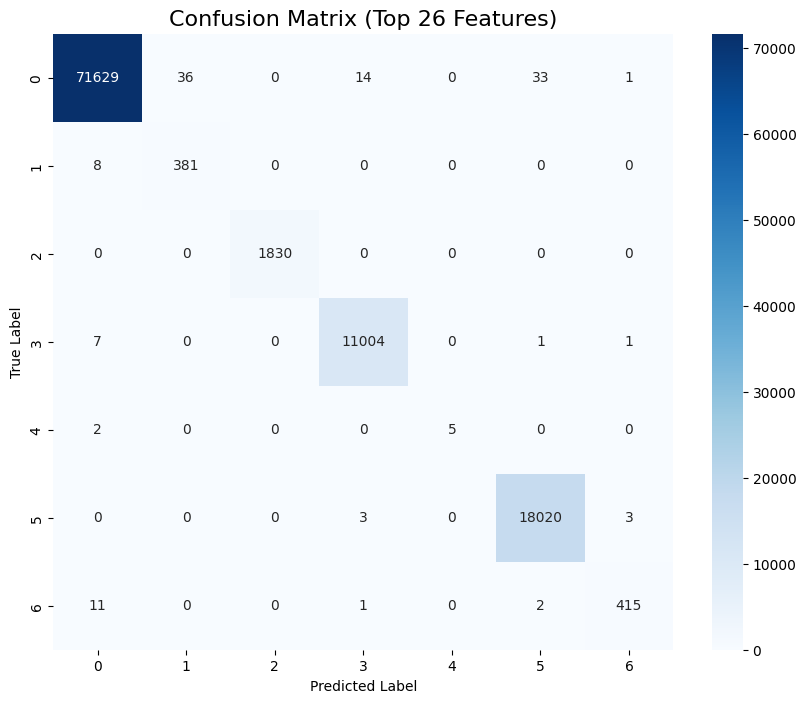

In [8]:
# Make predictions on the test set
y_pred = final_model.predict(X_test_selected)

# Print Classification Report
print("--- Final Classification Report ---")
print(classification_report(y_test, y_pred, digits=4))

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Top 26 Features)', fontsize=16)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [9]:
# --- Simplified Metrics Report ---

from sklearn.metrics import accuracy_score, f1_score

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')

print("="*30)
print(f"FINAL MODEL PERFORMANCE")
print("="*30)
print(f"Accuracy:      {acc:.4%}")
print(f"Weighted F1:   {f1_weighted:.4%}")
print(f"Macro F1:      {f1_macro:.4%}")
print("="*30)

FINAL MODEL PERFORMANCE
Accuracy:      99.8811%
Weighted F1:   99.8815%
Macro F1:      96.4742%


# 8️⃣. Validation: Overfitting Check
**Rationale:** Before saving the model, we must ensure it hasn't "memorized" the training data. We compare the accuracy on the **Training Set** (data it saw) vs. the **Testing Set** (data it hasn't seen).

* **Good Fit:** The scores are very close (e.g., Train=99.9%, Test=99.8%).
* **Overfitting:** Training score is significantly higher than Test score.

In [13]:
from sklearn.metrics import accuracy_score

# 1. Get predictions for both sets
print("Predicting on Training set...")
train_pred = final_model.predict(X_train_selected)

print("Predicting on Testing set...")
test_pred = final_model.predict(X_test_selected)

# 2. Calculate Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

# 3. Print Comparison
print("\n" + "="*30)
print("OVERFITTING CHECK")
print("="*30)
print(f"Training Accuracy: {train_acc:.4%}")
print(f"Testing Accuracy:  {test_acc:.4%}")

diff = train_acc - test_acc
print(f"Gap:               {diff:.4%}")

if diff < 0.02:
    print("\n✅ STATUS: GOOD FIT (No Overfitting)")
else:
    print("\n⚠️ STATUS: POTENTIAL OVERFITTING")

Predicting on Training set...
Predicting on Testing set...

OVERFITTING CHECK
Training Accuracy: 99.9432%
Testing Accuracy:  99.8811%
Gap:               0.0621%

✅ STATUS: GOOD FIT (No Overfitting)


# 9️⃣  Save Final Model (Pickle)
**Rationale:** We save the trained model to a file so it can be deployed for inference (predicting attacks on new traffic) without needing to retrain. We use Python's standard `pickle` module to serialize the model object.

In [14]:
import pickle
import os

model_dir = "/content/drive/MyDrive/Depi Project/Models"
os.makedirs(model_dir, exist_ok=True)

# Path
pickle_path = os.path.join(model_dir, "random_forest_nids.pkl")

# Save
with open(pickle_path, 'wb') as f:
    pickle.dump(final_model, f)

print(f" Model saved with Pickle: {pickle_path}")

 Model saved with Pickle: /content/drive/MyDrive/Depi Project/Models/random_forest_nids.pkl
